# 04 — ResNet-50 baseline
This 11-class, single-label experiment repeats the Swin-Tiny baseline with the same cleaned CSV, splits, preprocessing, loss, optimizer and schedule. Only the model architecture changes.
Train the new classifier for 2 epochs at 5e-4, then fine-tune the whole network for 13 epochs at 5e-5. Validation macro F1 selects the checkpoint; the test set is evaluated once at the end.

## 1. Imports

Use plain PyTorch, the official torchvision ResNet-50 and scikit-learn metrics. Preprocessing stays in PIL and PyTorch, exactly as in notebooks 02 and 03.

In [1]:
from pathlib import Path
import json
import platform
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
)

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__, "| torchvision:", torchvision.__version__)

Python: 3.11.15
PyTorch: 2.12.1+cu126 | torchvision: 0.27.1+cu126


## 2. Paths, settings and seeds

All experiment values sit here and match the Swin-Tiny run. Batch size 16 is the starting value; reduce it to 8, then 4, only if CUDA actually runs out of memory.

In [2]:
PROJECT_ROOT = Path.cwd()  # Change this to your project location if needed.
CLEANED_CSV = PROJECT_ROOT / "DATASET" / "cleaned_top11_metadata.csv"
CHECKPOINT_PATH = PROJECT_ROOT / "best_resnet50.pth"
HISTORY_PATH = PROJECT_ROOT / "resnet50_training_history.csv"
RESULTS_PATH = PROJECT_ROOT / "resnet50_results.json"
WEIGHTS_CACHE = PROJECT_ROOT / ".torch_cache"
torch.hub.set_dir(str(WEIGHTS_CACHE))  # Reuse the downloaded weights on later runs.

SEED = 42
BATCH_SIZE = 16
NUM_WORKERS = 0
NUM_EPOCHS = 15
HEAD_EPOCHS = 2
HEAD_LR = 5e-4
FINETUNE_LR = 5e-5
WEIGHT_DECAY = 1e-4
assert 0 < HEAD_EPOCHS < NUM_EPOCHS
SETTINGS = {"model": "ResNet-50", "weights": "ResNet50_Weights.DEFAULT", "input_size": 224,
            "seed": SEED, "batch_size": BATCH_SIZE, "num_epochs": NUM_EPOCHS, "head_epochs": HEAD_EPOCHS,
            "head_lr": HEAD_LR, "finetune_lr": FINETUNE_LR, "weight_decay": WEIGHT_DECAY,
            "optimizer": "AdamW", "loss": "CrossEntropyLoss", "scheduler": None}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"
print("Device:", device, "| CUDA mixed precision:", use_amp)
if use_amp:
    print("GPU:", torch.cuda.get_device_name(0))
print("Metadata:", CLEANED_CSV)
print(f"Head: {HEAD_EPOCHS} epochs at {HEAD_LR}; full fine-tuning: {NUM_EPOCHS - HEAD_EPOCHS} epochs at {FINETUNE_LR}")

Device: cuda | CUDA mixed precision: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Metadata: c:\Users\aravi\OneDrive\Desktop\coding\FYP MR disease classification\DATASET\cleaned_top11_metadata.csv
Head: 2 epochs at 0.0005; full fine-tuning: 13 epochs at 5e-05


## 3. Load metadata and class mapping

Read the cleaned metadata without repeating cleaning or hashing. The model uses Target, while Class_Index keeps the original disease index. Actual counts are compared with the expected sizes rather than assumed.

In [3]:
assert CLEANED_CSV.is_file(), f"Missing {CLEANED_CSV}. Check PROJECT_ROOT or run notebook 01."
df = pd.read_csv(CLEANED_CSV, dtype={"Image_ID": "string", "Class_Index": "string"})
assert set(df["Split"]) == {"train", "val", "test"}
assert df["Target"].notna().all() and df["Target"].mod(1).eq(0).all()
df["Target"] = df["Target"].astype("int64")
assert set(df["Target"]) == set(range(11))
assert df.groupby("Disease")["Target"].nunique().eq(1).all()
assert df.groupby("Target")["Disease"].nunique().eq(1).all()
assert not df.duplicated(["Split", "Image_ID"]).any()

class_table = df[["Target", "Disease", "Class_Index"]].drop_duplicates().sort_values("Target").reset_index(drop=True)
class_table["Class_Index"] = class_table["Class_Index"].astype(int)
assert len(class_table) == 11
class_names = class_table["Disease"].tolist()
TARGET_MAP = {disease: int(target) for disease, target in zip(class_table["Disease"], class_table["Target"])}
CLASS_MAPPING = [{"target": int(row.Target), "disease": row.Disease, "class_index": int(row.Class_Index)}
                 for row in class_table.itertuples()]
num_classes = len(class_names)
LABELS = list(range(num_classes))
counts = df["Split"].value_counts().reindex(["train", "val", "test"], fill_value=0)
expected = pd.Series({"train": 911, "val": 278, "test": 304})
display(pd.DataFrame({"actual": counts, "expected": expected, "difference": counts - expected}))
print("Total:", len(df), "| classes:", num_classes)
print("Class-to-target mapping:", TARGET_MAP)
display(class_table)
display(pd.crosstab(df["Disease"], df["Split"]).reindex(class_names))

,actual,expected,difference
train,911,911,0
val,278,278,0
test,304,304,0


Total: 1493 | classes: 11
Class-to-target mapping: {'DR': 0, 'MH': 1, 'ODC': 2, 'DN': 3, 'BRVO': 4, 'ODE': 5, 'MYA': 6, 'ARMD': 7, 'RS': 8, 'CSR': 9, 'CRVO': 10}


,Target,Disease,Class_Index
0,0,DR,0
1,1,MH,2
2,2,ODC,11
3,3,DN,3
4,4,BRVO,5
5,5,ODE,16
6,6,MYA,4
7,7,ARMD,1
8,8,RS,13
9,9,CSR,10


Split,test,train,val
Disease,,,
DR,80,240,81
MH,73,180,62
ODC,18,119,18
DN,30,89,33
BRVO,18,54,10
ODE,15,52,14
MYA,17,46,12
ARMD,18,34,17
RS,14,39,14


## 4. Reuse image-path resolution

This is the path resolver from notebook 02, resolving relative paths from the project root. Check that every selected image exists; no hashing or image audit is repeated.

In [4]:
def resolve_image_path(row):
    for column in ["Image_Path", "Output_Path", "Resolved_Source_Path", "Source_Path"]:
        value = row.get(column)
        if pd.isna(value) or not str(value).strip():
            continue
        path = Path(str(value))
        choice = path if path.is_absolute() else PROJECT_ROOT / path
        if choice.is_file():
            return choice
    fallback = PROJECT_ROOT / "DATASET" / str(row["Split"]) / f"Class_{row['Class_Index']}_{row['Disease']}" / f"{row['Image_ID']}.png"
    if fallback.is_file():
        return fallback
    raise FileNotFoundError(f"No image for {row['Split']} / {row['Image_ID']}")

resolved_paths = [resolve_image_path(row) for _, row in df.iterrows()]
print("Resolved images:", len(resolved_paths), "| first path:", resolved_paths[0])

Resolved images: 1493 | first path: c:\Users\aravi\OneDrive\Desktop\coding\FYP MR disease classification\DATASET\train\Class_0_DR\1.png


## 5. Reuse the conservative crop

The existing crop is copied without changing its threshold or safety checks. It returns the original image when foreground detection is unsafe.

In [5]:
def safe_fundus_crop(image, threshold=8, margin_fraction=0.03,
                     min_foreground_fraction=0.10, min_side_fraction=0.40):
    small = image.convert("L")
    small.thumbnail((512, 512))
    mask = np.asarray(small) > threshold
    if mask.mean() < min_foreground_fraction:
        return image
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return image
    width, height = image.size
    left = int(xs.min() * width / small.width)
    top = int(ys.min() * height / small.height)
    right = min(width, int((xs.max() + 1) * width / small.width))
    bottom = min(height, int((ys.max() + 1) * height / small.height))
    if (right - left) < min_side_fraction * width or (bottom - top) < min_side_fraction * height:
        return image
    margin_x, margin_y = int(width * margin_fraction), int(height * margin_fraction)
    box = (max(0, left - margin_x), max(0, top - margin_y),
           min(width, right + margin_x), min(height, bottom + margin_y))
    return image.crop(box)

print("Crop: threshold=8, margin=0.03, minimum foreground=0.10, minimum side=0.40")

Crop: threshold=8, margin=0.03, minimum foreground=0.10, minimum side=0.40


## 6. Reuse square padding

The crop is centered on a black square before resizing, which preserves the retinal image proportions.

In [6]:
def square_pad(image):
    width, height = image.size
    side = max(width, height)
    canvas = Image.new("RGB", (side, side), (0, 0, 0))
    canvas.paste(image, ((side - width) // 2, (side - height) // 2))
    return canvas

print("Square padding: centered RGB image, black background")

Square padding: centered RGB image, black background


## 7. Reuse training and evaluation transforms

These are the unchanged transforms from notebook 02, so ResNet-50 sees exactly the same inputs as Swin-Tiny. Training adds a horizontal flip, ±10° rotation and brightness/contrast factors between 0.9 and 1.1; validation and test are deterministic.

In [7]:
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]
mean_tensor = torch.tensor(MEAN, dtype=torch.float32).view(3, 1, 1)
std_tensor = torch.tensor(STD, dtype=torch.float32).view(3, 1, 1)

def to_normalized_tensor(image):
    tensor = torch.from_numpy(np.asarray(image, dtype=np.float32).copy()).permute(2, 0, 1) / 255.0
    return (tensor - mean_tensor) / std_tensor

def eval_transform(image):
    image = safe_fundus_crop(image)
    image = square_pad(image)
    image = image.resize((224, 224), Image.Resampling.BICUBIC)
    return to_normalized_tensor(image)

def train_transform(image):
    image = safe_fundus_crop(image)
    image = square_pad(image)
    image = image.resize((224, 224), Image.Resampling.BICUBIC)
    if random.random() < 0.5:
        image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
    image = image.rotate(random.uniform(-10, 10), resample=Image.Resampling.BICUBIC)
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.90, 1.10))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.90, 1.10))
    return to_normalized_tensor(image)

print("Input: 224 x 224 | mean:", MEAN, "| std:", STD)
print("Training: crop, pad, bicubic resize, mild augmentation, tensor, normalization")
print("Validation/test: crop, pad, bicubic resize, tensor, normalization")

Input: 224 x 224 | mean: [0.485, 0.456, 0.406] | std: [0.229, 0.224, 0.225]
Training: crop, pad, bicubic resize, mild augmentation, tensor, normalization
Validation/test: crop, pad, bicubic resize, tensor, normalization


## 8. Reuse FundusDataset and create loaders

The Dataset class and the original splits are reused unchanged. Training is shuffled with a seeded generator; validation and test keep metadata order.

In [8]:
class FundusDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(resolve_image_path(row)) as file:
            image = file.convert("RGB")
        image_tensor = self.transform(image)
        target = int(row["Target"])
        return image_tensor, target

train_dataset = FundusDataset(df.loc[df["Split"].eq("train")], train_transform)
val_dataset = FundusDataset(df.loc[df["Split"].eq("val")], eval_transform)
test_dataset = FundusDataset(df.loc[df["Split"].eq("test")], eval_transform)
train_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=use_amp, generator=train_generator)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=use_amp)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=use_amp)
print("Dataset sizes:", len(train_dataset), len(val_dataset), len(test_dataset))
print("Batch size:", BATCH_SIZE, "| workers:", NUM_WORKERS)

Dataset sizes: 911 278 304
Batch size: 16 | workers: 0


## 9. Batch checks

Inspect one batch from each split without making predictions. Check shapes, types, finite values and the target range, then confirm evaluation preprocessing repeats exactly.

In [9]:
batches = {}
for name, loader in [("train", train_loader), ("val", val_loader), ("test", test_loader)]:
    images, targets = next(iter(loader))
    batches[name] = (images, targets)
    assert images.ndim == 4 and images.shape[1:] == (3, 224, 224)
    assert images.shape[0] == targets.shape[0]
    assert images.dtype == torch.float32 and targets.dtype == torch.int64
    assert torch.isfinite(images).all()
    assert targets.ge(0).all() and targets.lt(num_classes).all()
    print(name, "images:", tuple(images.shape), "targets:", tuple(targets.shape),
          "dtypes:", images.dtype, targets.dtype, "range:", int(targets.min()), int(targets.max()))
assert torch.equal(val_dataset[0][0], val_dataset[0][0])
print("Validation preprocessing repeats exactly.")
train_images, train_targets = batches["train"]

train images: (16, 3, 224, 224) targets: (16,) dtypes: torch.float32 torch.int64 range: 0 10
val images: (16, 3, 224, 224) targets: (16,) dtypes: torch.float32 torch.int64 range: 0 9
test images: (16, 3, 224, 224) targets: (16,) dtypes: torch.float32 torch.int64 range: 0 9
Validation preprocessing repeats exactly.


## 10. Load ImageNet-pretrained ResNet-50

`build_model` loads the official torchvision weights (the first run may download them) and replaces the 1000-class `fc` layer with a single 11-output linear layer. The same function is used again later to rebuild a clean model after the sanity checks.

In [10]:
weights = ResNet50_Weights.DEFAULT

def build_model():
    model = resnet50(weights=weights)
    print("Original classifier:", model.fc)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    print("New classifier:", model.fc)
    return model.to(device)

print("Pretrained weights:", weights.name, "(ImageNet-1K)")
model = build_model()
print("Total parameters:", sum(parameter.numel() for parameter in model.parameters()))

Pretrained weights: IMAGENET1K_V2 (ImageNet-1K)
Original classifier: Linear(in_features=2048, out_features=1000, bias=True)
New classifier: Linear(in_features=2048, out_features=11, bias=True)
Total parameters: 23530571


## 11. Freeze the backbone and prepare head training

Only the new `fc` layer receives gradients during the first two epochs. CUDA mixed precision uses `torch.autocast` and `torch.amp.GradScaler`; both are disabled on CPU.

In [11]:
for parameter in model.parameters():
    parameter.requires_grad = False
for parameter in model.fc.parameters():
    parameter.requires_grad = True
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.fc.parameters(), lr=HEAD_LR, weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
print("Trainable head parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))
print("Head learning rate:", HEAD_LR, "| weight decay:", WEIGHT_DECAY)

Trainable head parameters: 22539
Head learning rate: 0.0005 | weight decay: 0.0001


## 12. Train one epoch

During head-only epochs the frozen backbone stays in `eval()` mode so its BatchNorm running statistics do not change; only `fc` is in training mode. During full fine-tuning the whole model uses normal `train()` mode, so BatchNorm adapts. Loss is cross-entropy on raw logits, averaged per image.

In [12]:
def train_one_epoch(loader, head_only):
    if head_only:
        model.eval()
        model.fc.train()
    else:
        model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, targets in loader:
        images = images.to(device, non_blocking=use_amp)
        targets = targets.to(device, non_blocking=use_amp)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
            logits = model(images)
            loss = criterion(logits, targets)
        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite training loss; stop and inspect the batch.")
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * targets.size(0)
        correct += (logits.argmax(dim=1) == targets).sum().item()
        total += targets.size(0)
    return total_loss / total, correct / total

print("Training function ready for head-only and full fine-tuning stages.")

Training function ready for head-only and full fine-tuning stages.


## 13. Evaluate and calculate metrics

Evaluation disables gradients and returns loss, accuracy, predictions and true targets; it is reused for validation and test. The metric function always uses all 11 labels with zero handling for undefined values.

In [13]:
def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    predictions, true_targets = [], []
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device, non_blocking=use_amp)
            targets = targets.to(device, non_blocking=use_amp)
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
                logits = model(images)
                loss = criterion(logits, targets)
            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite evaluation loss.")
            predicted = logits.argmax(dim=1)
            total_loss += loss.item() * targets.size(0)
            correct += (predicted == targets).sum().item()
            total += targets.size(0)
            predictions.extend(predicted.cpu().tolist())
            true_targets.extend(targets.cpu().tolist())
    return total_loss / total, correct / total, np.array(predictions), np.array(true_targets)

def classification_metrics(targets, predictions, loss):
    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        targets, predictions, labels=LABELS, average="macro", zero_division=0)
    _, _, weighted_f1, _ = precision_recall_fscore_support(
        targets, predictions, labels=LABELS, average="weighted", zero_division=0)
    return {"loss": float(loss), "accuracy": float(accuracy_score(targets, predictions)),
            "macro_precision": float(precision), "macro_recall": float(recall),
            "macro_f1": float(macro_f1), "weighted_f1": float(weighted_f1)}

print("Evaluation and classification metric functions ready.")

Evaluation and classification metric functions ready.


## 14. Model and one-step sanity checks

Check the `[B, 11]` output shape and a finite loss on one training batch, then run one head-only update. The head should change while the backbone weights and BatchNorm running statistics stay unchanged; the reset cell below discards this update.

In [14]:
model.eval()
with torch.no_grad():
    logits = model(train_images.to(device))
    sanity_loss = criterion(logits, train_targets.to(device))
assert logits.shape == (train_images.size(0), num_classes)
assert torch.isfinite(logits).all() and torch.isfinite(sanity_loss)
print("Output shape:", tuple(logits.shape), "| cross-entropy:", sanity_loss.item())

conv_before = model.conv1.weight.detach().clone()
bn_before = model.bn1.running_mean.detach().clone()
head_before = model.fc.weight.detach().clone()
step_loss, step_accuracy = train_one_epoch([(train_images, train_targets)], head_only=True)
assert torch.equal(conv_before, model.conv1.weight.detach())
assert torch.equal(bn_before, model.bn1.running_mean)
assert not torch.equal(head_before, model.fc.weight.detach())
assert all(p.grad is None for name, p in model.named_parameters() if not name.startswith("fc."))
assert all(torch.isfinite(p.grad).all() for p in model.fc.parameters())
print("Mini step passed: frozen backbone and BatchNorm statistics unchanged, classifier updated.")
print("Mini step loss:", step_loss, "| accuracy:", step_accuracy)
del conv_before, bn_before, head_before

Output shape: (16, 11) | cross-entropy: 2.347433090209961


Mini step passed: frozen backbone and BatchNorm statistics unchanged, classifier updated.
Mini step loss: 2.3475341796875 | accuracy: 0.1875


## 15. Optional small loss-reduction check

Leave this disabled for a normal run. When enabled, it repeats the same training batch for a few head updates so you can check that the loss decreases.

In [15]:
RUN_TINY_OVERFIT = False
if RUN_TINY_OVERFIT:
    tiny_losses = []
    for step in range(8):
        tiny_loss, _ = train_one_epoch([(train_images, train_targets)], head_only=True)
        tiny_losses.append(tiny_loss)
    print("Fixed training-batch losses:", [round(value, 4) for value in tiny_losses])
else:
    print("Optional small loss-reduction check skipped.")

Optional small loss-reduction check skipped.


## 16. Reset everything before the real experiment

Reset the seeds and rebuild a fresh pretrained ResNet-50 so none of the diagnostic updates carry over. The optimizer, scaler, shuffle generator and history are also recreated.

In [16]:
del model, optimizer, scaler
if use_amp:
    torch.cuda.empty_cache()
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
train_generator.manual_seed(SEED)
model = build_model()
for parameter in model.parameters():
    parameter.requires_grad = False
for parameter in model.fc.parameters():
    parameter.requires_grad = True
optimizer = torch.optim.AdamW(model.fc.parameters(), lr=HEAD_LR, weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
history = []
best_val_macro_f1 = -1.0
best_epoch = None
training_finished = False
print("Fresh model ready. Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Original classifier: Linear(in_features=2048, out_features=1000, bias=True)
New classifier: Linear(in_features=2048, out_features=11, bias=True)
Fresh model ready. Trainable parameters: 22539


## 17. Train both stages and save the best checkpoint

Epochs 1–2 train only `fc` at 5e-4. At epoch 3, every parameter is unfrozen and a new AdamW optimizer at 5e-5 continues from the head-stage weights. The checkpoint with the best validation macro F1 from either stage is saved, and the history is written after every epoch.

In [17]:
STAGE_NAMES = {"head": "Classifier Head Only", "full": "Full Fine-Tuning"}
for epoch in range(1, NUM_EPOCHS + 1):
    head_only = epoch <= HEAD_EPOCHS
    stage = "head" if head_only else "full"
    if epoch == HEAD_EPOCHS + 1:
        for parameter in model.parameters():
            parameter.requires_grad = True
        assert all(parameter.requires_grad for parameter in model.parameters())
        optimizer = torch.optim.AdamW(model.parameters(), lr=FINETUNE_LR, weight_decay=WEIGHT_DECAY)
        print("\nStage 2 started: full ResNet-50 fine-tuning | LR:", FINETUNE_LR,
              "| trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

    train_loss, train_accuracy = train_one_epoch(train_loader, head_only=head_only)
    val_loss, val_accuracy, val_predictions, val_targets = evaluate(val_loader)
    val_macro_f1 = float(precision_recall_fscore_support(
        val_targets, val_predictions, labels=LABELS, average="macro", zero_division=0)[2])
    history.append({"epoch": epoch, "stage": stage, "learning_rate": optimizer.param_groups[0]["lr"],
                    "train_loss": train_loss, "train_accuracy": train_accuracy,
                    "val_loss": val_loss, "val_accuracy": val_accuracy, "val_macro_f1": val_macro_f1})
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    print(f"Stage: {STAGE_NAMES[stage]}")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_accuracy:.4f} | Val Macro F1: {val_macro_f1:.4f}")
    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        best_epoch = epoch
        torch.save({"model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(),
                    "epoch": epoch, "stage": stage, "best_val_macro_f1": best_val_macro_f1,
                    "target_map": TARGET_MAP, "class_mapping": CLASS_MAPPING,
                    "num_classes": num_classes, "settings": SETTINGS}, CHECKPOINT_PATH)
        print("  Saved new best checkpoint:", CHECKPOINT_PATH.name)
    pd.DataFrame(history).to_csv(HISTORY_PATH, index=False)

training_finished = len(history) == NUM_EPOCHS
print("\nEpochs completed:", len(history), "| best epoch:", best_epoch, "| best validation macro F1:", best_val_macro_f1)


Epoch 1/15
Stage: Classifier Head Only
Train Loss: 1.9881 | Train Accuracy: 0.3458
Val Loss: 1.7928 | Val Accuracy: 0.4568 | Val Macro F1: 0.1547
  Saved new best checkpoint: best_resnet50.pth



Epoch 2/15
Stage: Classifier Head Only
Train Loss: 1.6467 | Train Accuracy: 0.4874
Val Loss: 1.5937 | Val Accuracy: 0.4856 | Val Macro F1: 0.2438
  Saved new best checkpoint: best_resnet50.pth

Stage 2 started: full ResNet-50 fine-tuning | LR: 5e-05 | trainable parameters: 23530571



Epoch 3/15
Stage: Full Fine-Tuning
Train Loss: 1.4956 | Train Accuracy: 0.5137
Val Loss: 1.3801 | Val Accuracy: 0.5252 | Val Macro F1: 0.2544


  Saved new best checkpoint: best_resnet50.pth



Epoch 4/15
Stage: Full Fine-Tuning
Train Loss: 1.1270 | Train Accuracy: 0.6334
Val Loss: 1.1938 | Val Accuracy: 0.6079 | Val Macro F1: 0.3917


...


Epoch 12/15
Stage: Full Fine-Tuning
Train Loss: 0.1213 | Train Accuracy: 0.9671
Val Loss: 0.6773 | Val Accuracy: 0.7518 | Val Macro F1: 0.7280


  Saved new best checkpoint: best_resnet50.pth



Epoch 13/15
Stage: Full Fine-Tuning
Train Loss: 0.0947 | Train Accuracy: 0.9780
Val Loss: 0.7755 | Val Accuracy: 0.7446 | Val Macro F1: 0.7242



Epoch 14/15
Stage: Full Fine-Tuning
Train Loss: 0.0668 | Train Accuracy: 0.9857
Val Loss: 0.8554 | Val Accuracy: 0.7482 | Val Macro F1: 0.7088



Epoch 15/15
Stage: Full Fine-Tuning
Train Loss: 0.0716 | Train Accuracy: 0.9857
Val Loss: 0.8728 | Val Accuracy: 0.7374 | Val Macro F1: 0.6930

Epochs completed: 15 | best epoch: 12 | best validation macro F1: 0.7280269675275176


## 18. Plot learning curves

Plot losses, accuracies and validation macro F1 to inspect convergence and overfitting. The dotted line marks the switch from head training to full fine-tuning.

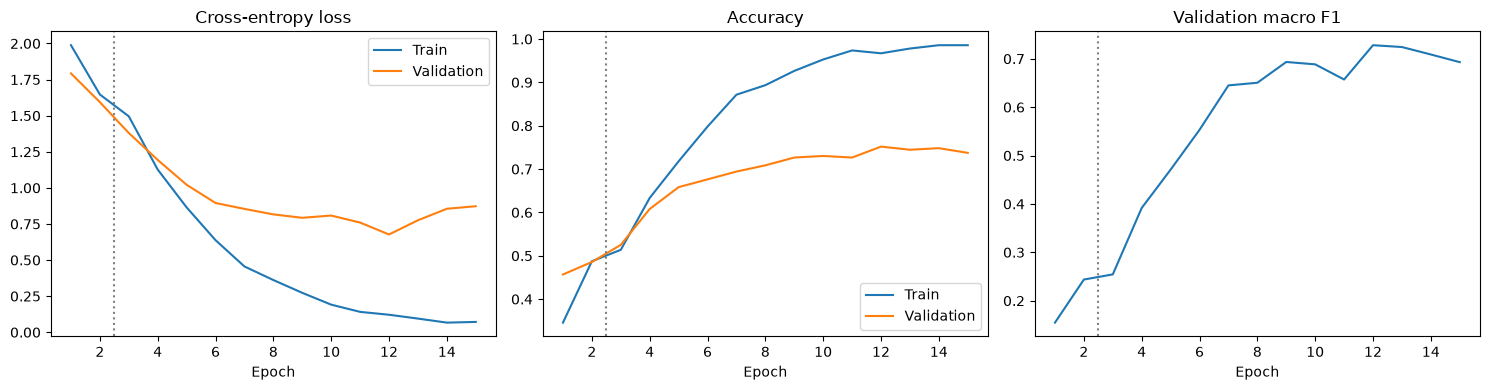

In [18]:
history_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation")
axes[0].set_title("Cross-entropy loss")
axes[0].legend()
axes[1].plot(history_df["epoch"], history_df["train_accuracy"], label="Train")
axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="Validation")
axes[1].set_title("Accuracy")
axes[1].legend()
axes[2].plot(history_df["epoch"], history_df["val_macro_f1"])
axes[2].set_title("Validation macro F1")
for axis in axes:
    axis.set_xlabel("Epoch")
    axis.axvline(HEAD_EPOCHS + 0.5, color="gray", linestyle=":")
plt.tight_layout()

## 19. Reload the selected checkpoint

Restore the checkpoint with the highest validation macro F1, which may come from either stage. Verify that its class mapping matches the current dataset before evaluating.

In [19]:
assert training_finished, "Finish the training experiment before final evaluation."
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=True)
assert checkpoint["target_map"] == TARGET_MAP
assert checkpoint["class_mapping"] == CLASS_MAPPING
assert checkpoint["num_classes"] == num_classes
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print("Selected epoch:", checkpoint["epoch"], "| stage:", checkpoint["stage"])
print("Selected validation macro F1:", checkpoint["best_val_macro_f1"])

Selected epoch: 12 | stage: full
Selected validation macro F1: 0.7280269675275176


## 20. Final validation results

Evaluate the selected weights on the full validation set. Macro metrics are reported alongside accuracy because the disease counts are imbalanced.

In [20]:
val_loss, val_accuracy, val_predictions, val_targets = evaluate(val_loader)
validation_metrics = classification_metrics(val_targets, val_predictions, val_loss)
display(pd.Series(validation_metrics, name="Validation"))
print(classification_report(val_targets, val_predictions, labels=LABELS,
                            target_names=class_names, digits=4, zero_division=0))

loss               0.677335
accuracy           0.751799
macro_precision    0.744326
macro_recall       0.727320
macro_f1           0.728027
weighted_f1        0.748295
Name: Validation, dtype: float64

              precision    recall  f1-score   support

          DR     0.7978    0.8765    0.8353        81
          MH     0.8136    0.7742    0.7934        62
         ODC     0.6842    0.7222    0.7027        18
          DN     0.5000    0.4848    0.4923        33
        BRVO     0.5000    0.6000    0.5455        10
         ODE     1.0000    0.8571    0.9231        14
         MYA     0.8000    1.0000    0.8889        12
        ARMD     0.7778    0.4118    0.5385        17
          RS     0.8571    0.8571    0.8571        14
         CSR     0.6000    0.6667    0.6316         9
        CRVO     0.8571    0.7500    0.8000         8

    accuracy                         0.7518       278
   macro avg     0.7443    0.7273    0.7280       278
weighted avg     0.7552    0.7518    0.7483       278



## 21. One final test evaluation

Run this only after model selection is finished. The selected checkpoint is evaluated once, and these predictions are reused for the confusion matrix, per-class table and mistake inspection.

In [21]:
assert training_finished
test_loss, test_accuracy, test_predictions, test_targets = evaluate(test_loader)
test_metrics = classification_metrics(test_targets, test_predictions, test_loss)
display(pd.Series(test_metrics, name="Test"))
print(classification_report(test_targets, test_predictions, labels=LABELS,
                            target_names=class_names, digits=4, zero_division=0))

loss               0.673093
accuracy           0.809211
macro_precision    0.854015
macro_recall       0.746549
macro_f1           0.780554
weighted_f1        0.804538
Name: Test, dtype: float64

              precision    recall  f1-score   support

          DR     0.8068    0.8875    0.8452        80
          MH     0.8519    0.9452    0.8961        73
         ODC     0.7619    0.8889    0.8205        18
          DN     0.5172    0.5000    0.5085        30
        BRVO     0.6667    0.7778    0.7179        18
         ODE     0.9286    0.8667    0.8966        15
         MYA     0.9444    1.0000    0.9714        17
        ARMD     0.9167    0.6111    0.7333        18
          RS     1.0000    0.5714    0.7273        14
         CSR     1.0000    0.5385    0.7000        13
        CRVO     1.0000    0.6250    0.7692         8

    accuracy                         0.8092       304
   macro avg     0.8540    0.7465    0.7806       304
weighted avg     0.8205    0.8092    0.8045       304



## 22. Test confusion matrix

Rows are true diseases and columns are predictions. Both axes follow the model's Target order (0 = DR … 10 = CRVO).

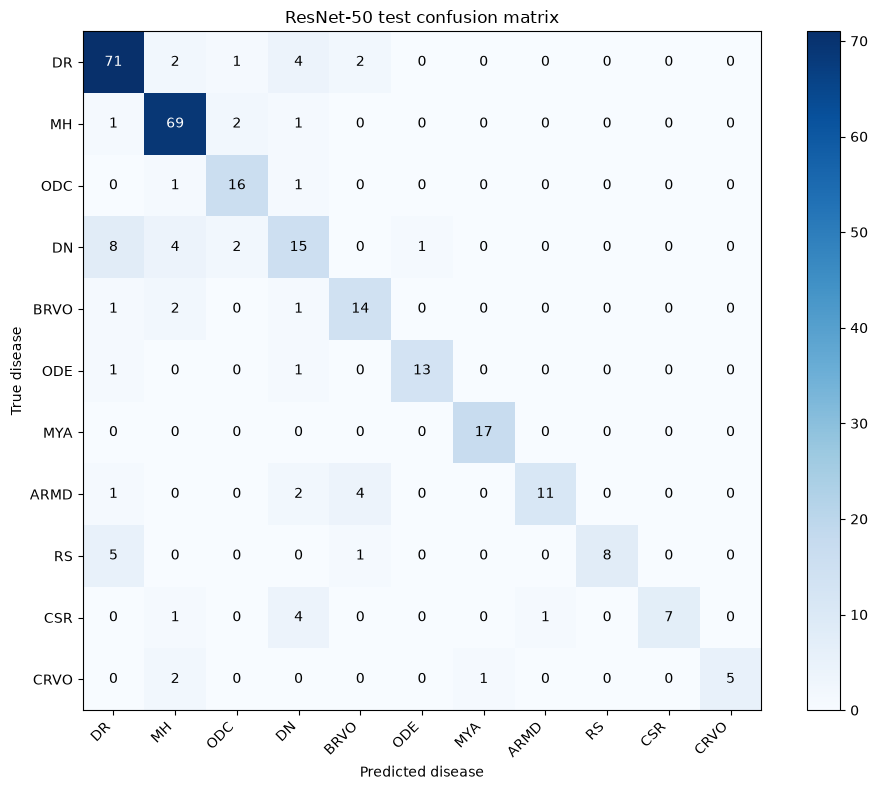

In [22]:
matrix = confusion_matrix(test_targets, test_predictions, labels=LABELS)
fig, axis = plt.subplots(figsize=(10, 8))
picture = axis.imshow(matrix, cmap="Blues")
fig.colorbar(picture, ax=axis)
axis.set_xticks(LABELS, class_names, rotation=45, ha="right")
axis.set_yticks(LABELS, class_names)
axis.set_xlabel("Predicted disease")
axis.set_ylabel("True disease")
axis.set_title("ResNet-50 test confusion matrix")
for row in LABELS:
    for column in LABELS:
        axis.text(column, row, str(matrix[row, column]), ha="center", va="center",
                  color="white" if matrix[row, column] > matrix.max() / 2 else "black")
plt.tight_layout()

## 23. Per-class test results

Join precision, recall, F1 and support to the disease mapping. Rows are sorted by the original Class_Index, as in the Swin-Tiny notebook, and the model Target is shown too.

In [23]:
precision, recall, f1, support = precision_recall_fscore_support(
    test_targets, test_predictions, labels=LABELS, average=None, zero_division=0)
per_class_results = class_table.assign(Support=support, Precision=precision, Recall=recall, F1=f1)
per_class_results = per_class_results.sort_values("Class_Index").reset_index(drop=True)
display(per_class_results[["Disease", "Class_Index", "Target", "Support", "Precision", "Recall", "F1"]])

,Disease,Class_Index,Target,Support,Precision,Recall,F1
0,DR,0,0,80,0.806818,0.887500,0.845238
1,ARMD,1,7,18,0.916667,0.611111,0.733333
2,MH,2,1,73,0.851852,0.945205,0.896104
3,DN,3,3,30,0.517241,0.500000,0.508475
4,MYA,4,6,17,0.944444,1.000000,0.971429
5,BRVO,5,4,18,0.666667,0.777778,0.717949
6,CSR,10,9,13,1.000000,0.538462,0.700000
7,ODC,11,2,18,0.761905,0.888889,0.820513
8,CRVO,12,10,8,1.000000,0.625000,0.769231
9,RS,13,8,14,1.000000,0.571429,0.727273


## 24. Optional inspection of wrong predictions

Show up to 12 misclassified test images using the deterministic test transform, de-normalized for display. The model is not run again; titles use the saved test predictions.

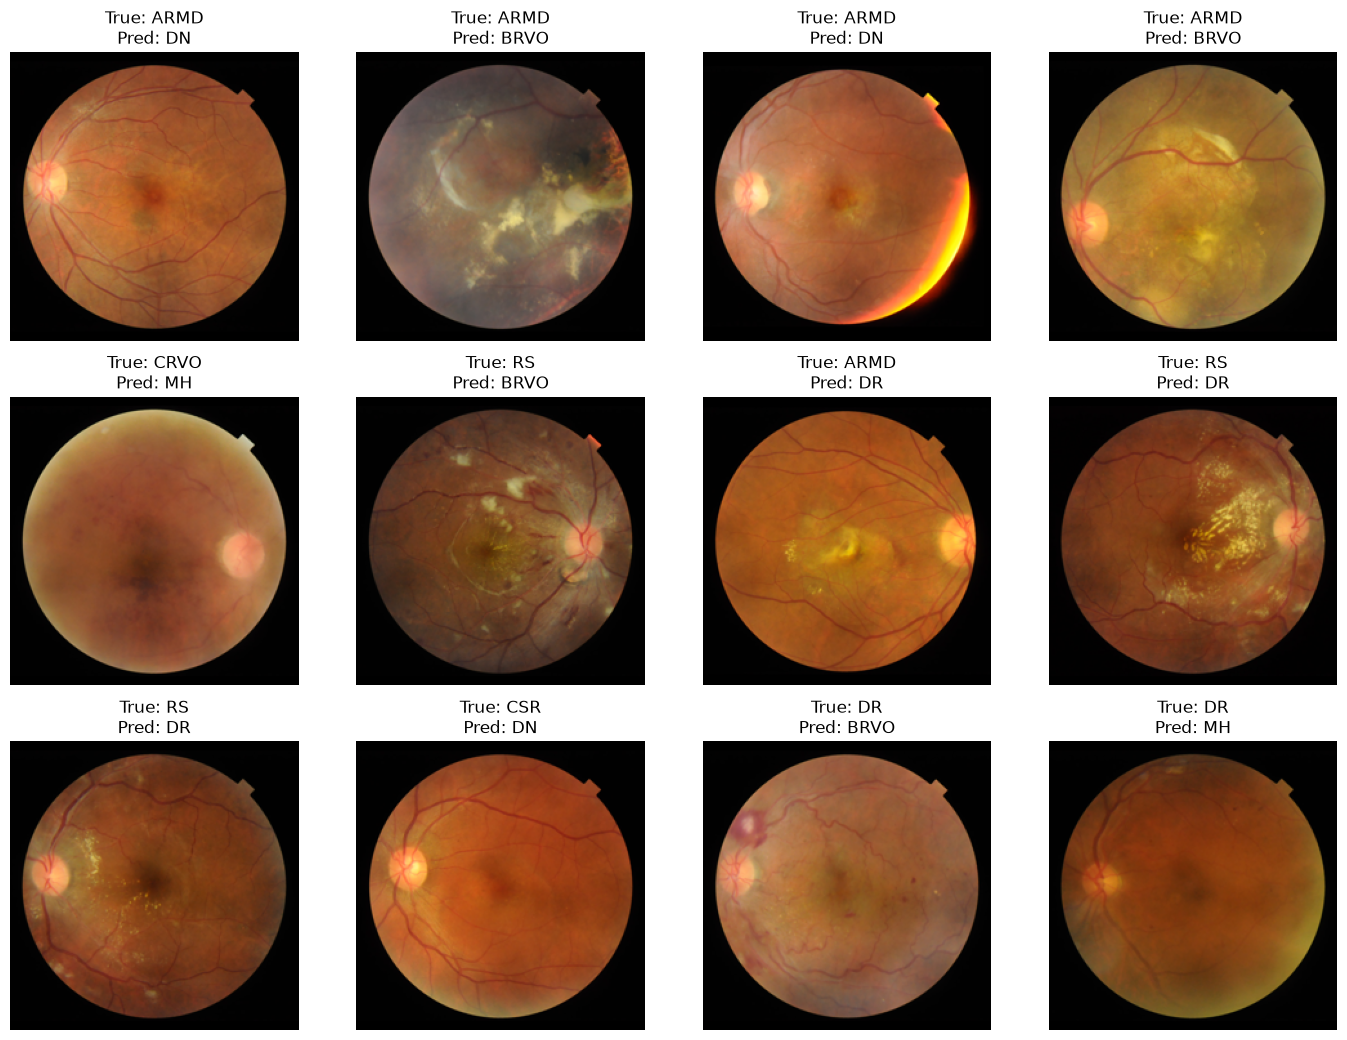

In [24]:
wrong_indices = np.flatnonzero(test_predictions != test_targets)[:12]
if len(wrong_indices) == 0:
    print("No misclassified test images.")
else:
    rows = (len(wrong_indices) + 3) // 4
    fig, axes = plt.subplots(rows, 4, figsize=(14, 3.5 * rows), squeeze=False)
    for axis in axes.flat:
        axis.axis("off")
    for axis, index in zip(axes.flat, wrong_indices):
        image, target = test_dataset[int(index)]
        picture = (image * std_tensor + mean_tensor).clamp(0, 1).permute(1, 2, 0).numpy()
        axis.imshow(picture)
        axis.set_title(f"True: {class_names[target]}\nPred: {class_names[int(test_predictions[index])]}")
    plt.tight_layout()

## 25. Save results and print the experiment summary

Save settings, class mapping and final metrics to a JSON file with the same keys as the Swin-Tiny metrics file, so the two runs can be compared directly. The summary reports the selected checkpoint, not the last epoch.

In [25]:
summary = {"model": "ResNet-50", "pretraining": weights.name, "num_classes": num_classes,
           "sample_counts": {split: int(counts[split]) for split in ["train", "val", "test"]},
           "input_size": [224, 224], "normalization_mean": MEAN, "normalization_std": STD,
           "loss": "CrossEntropyLoss", "optimizer": "AdamW", "weight_decay": WEIGHT_DECAY,
           "head_epochs": HEAD_EPOCHS, "head_learning_rate": HEAD_LR,
           "fine_tune_learning_rate": FINETUNE_LR, "batch_size": BATCH_SIZE,
           "epochs_trained": len(history), "seed": SEED, "device": str(device),
           "torch_version": str(torch.__version__), "torchvision_version": torchvision.__version__,
           "best_epoch": int(checkpoint["epoch"]), "best_stage": checkpoint["stage"],
           "best_validation_macro_f1": float(checkpoint["best_val_macro_f1"]),
           "target_map": TARGET_MAP, "validation_metrics": validation_metrics, "test_metrics": test_metrics}
with open(RESULTS_PATH, "w", encoding="utf-8") as file:
    json.dump(summary, file, indent=2)

print(f"""Model: ResNet-50
Pretraining: ImageNet-1K ({weights.name})
Classes: {num_classes}

Train samples: {len(train_dataset)}
Validation samples: {len(val_dataset)}
Test samples: {len(test_dataset)}

Input size: 224x224

Head training:
Epochs: {HEAD_EPOCHS}
LR: {HEAD_LR}

Full fine-tuning:
Epochs: {NUM_EPOCHS - HEAD_EPOCHS}
LR: {FINETUNE_LR}

Optimizer: AdamW
Weight decay: {WEIGHT_DECAY}
Loss: CrossEntropyLoss
Batch size: {BATCH_SIZE}

Best epoch: {checkpoint["epoch"]} ({checkpoint["stage"]})
Best validation macro F1: {checkpoint["best_val_macro_f1"]:.4f}

Test Accuracy: {test_metrics["accuracy"]:.4f}
Test Macro Precision: {test_metrics["macro_precision"]:.4f}
Test Macro Recall: {test_metrics["macro_recall"]:.4f}
Test Macro F1: {test_metrics["macro_f1"]:.4f}
Test Weighted F1: {test_metrics["weighted_f1"]:.4f}""")
print("\nSaved:", CHECKPOINT_PATH.name, HISTORY_PATH.name, RESULTS_PATH.name)

Model: ResNet-50
Pretraining: ImageNet-1K (IMAGENET1K_V2)
Classes: 11

Train samples: 911
Validation samples: 278
Test samples: 304

Input size: 224x224

Head training:
Epochs: 2
LR: 0.0005

Full fine-tuning:
Epochs: 13
LR: 5e-05

Optimizer: AdamW
Weight decay: 0.0001
Loss: CrossEntropyLoss
Batch size: 16

Best epoch: 12 (full)
Best validation macro F1: 0.7280

Test Accuracy: 0.8092
Test Macro Precision: 0.8540
Test Macro Recall: 0.7465
Test Macro F1: 0.7806
Test Weighted F1: 0.8045

Saved: best_resnet50.pth resnet50_training_history.csv resnet50_results.json
